In [19]:
!pip install autogluon
!pip insatll dask-expr

ERROR: unknown command "insatll" - maybe you meant "install"


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

pd.set_option('display.float_format', lambda x: '%.6f' % x) #* 將小數點顯示設置為點後六位

In [21]:
%cd '/content/drive/MyDrive/Colab Notebooks/專題'  #* 變更檔案路徑

/content/drive/MyDrive/Colab Notebooks/專題


In [22]:
raw = pd.read_csv('GPT4o.csv', index_col=0, parse_dates=True) 
#* 使用pandas讀取GPT4o,index_col指的是以第一列為索引, parse_dates為讓Pandas自動將csv檔案中日期格式的物件轉換為datetime object
non_numeric = raw[~raw['DP'].str.rstrip('%').str.replace('.', '',1).str.isdigit()]
#* .str.rstrip()為去除右側或指定字符, .replace(目標,標的,次數) 
#! ~ 取反操作, 布林值取反 True變False, 按位取反（數值）：以二進制01互換得出取反值
raw['DP'] = pd.to_numeric(raw['DP'].str.rstrip('%'), errors='coerce')/100
#* pd.to_numeric()：將轉換後的字符串轉換為數字類型（float 或 int）。 errors 預設為 = raise 彈出錯誤, 另有ignore及coerce(傳回NaN)
raw

,Sentiment Score,DP
date,,
2024/09/27,3.000000,-0.001580
2024/09/26,3.400000,0.004360
2024/09/26,3.260000,0.004360
2024/09/25,3.000000,0.014720
2024/09/25,3.400000,0.014720
...,...,...
2014/01/02,3.220000,0.000120
2014/01/02,2.670000,0.000120
2014/01/02,3.000000,0.000120


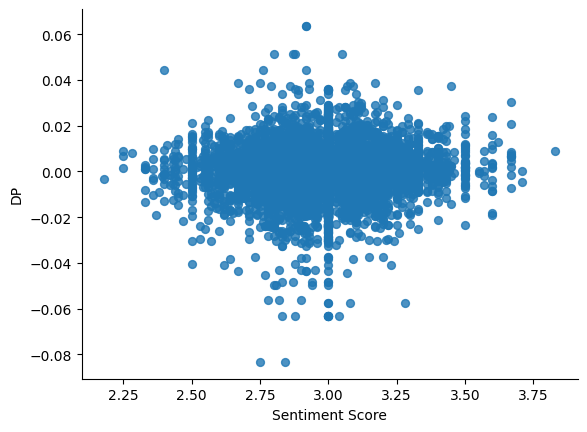

In [23]:
from matplotlib import pyplot as plt
raw.plot(kind='scatter', x='Sentiment Score', y='DP', s=32, alpha=.8)
#* s=32 為散點大小 alpha=0.8 為透明度
plt.gca().spines[['top', 'right',]].set_visible(False)
#* plt.gca()允許對圖表的各種屬性進行調整, .spines是圖表中邊框的屬性, 設定隱藏右邊及上方的資訊

In [24]:
raw.describe()

,Sentiment Score,DP
count,9019.000000,9017.000000
mean,2.987917,0.000476
std,0.173553,0.009681
min,2.180000,-0.083310
25%,2.900000,-0.003980
50%,3.000000,0.000800
75%,3.080000,0.005600
max,3.830000,0.063680


In [25]:
nan_labels = raw[raw['DP'].isna()]
print(nan_labels)
#* .isna 檢查沒數值的儲存格

                  Sentiment Score  DP
date                                 
2020/11/12 下午 04         2.800000 NaN
2016/02/05               3.000000 NaN


In [26]:
inf_labels = raw[~np.isfinite(raw['DP'])]
print(inf_labels)
#* .isfinite 檢查無限值

                  Sentiment Score  DP
date                                 
2020/11/12 下午 04         2.800000 NaN
2016/02/05               3.000000 NaN


In [27]:
raw = raw.dropna(subset=['DP'])
#* dropna(subset=DP)為刪除DP欄位缺失值,要刪除無限值可利用.NaN再使用dropna

In [28]:
print(np.isfinite(raw['DP']).all())
#* .all為檢查全部為真傳回True

True


In [29]:
raw['DP'] = np.where(raw['DP'] >= 0, 1, 0)
raw
#* np.where(condition, x, y) 會將結果傳回raw['DP']

<ipython-input-29-6d43881b8a20>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw['DP'] = np.where(raw['DP'] >= 0, 1, 0)


,Sentiment Score,DP
date,,
2024/09/27,3.000000,0
2024/09/26,3.400000,1
2024/09/26,3.260000,1
2024/09/25,3.000000,1
2024/09/25,3.400000,1
...,...,...
2014/01/02,3.220000,1
2014/01/02,2.670000,1
2014/01/02,3.000000,1


In [30]:
raw['DP'] = raw['DP'].astype(float)
#* .astype可以轉換不同類型

<ipython-input-30-1e1c5a1a6461>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw['DP'] = raw['DP'].astype(float)


In [31]:
raw

,Sentiment Score,DP
date,,
2024/09/27,3.000000,0.000000
2024/09/26,3.400000,1.000000
2024/09/26,3.260000,1.000000
2024/09/25,3.000000,1.000000
2024/09/25,3.400000,1.000000
...,...,...
2014/01/02,3.220000,1.000000
2014/01/02,2.670000,1.000000
2014/01/02,3.000000,1.000000


In [32]:
train_data, test_data = train_test_split(raw, test_size=0.2, random_state=42)
#* test_size = 0.2 測試只分兩成（通常情況）

In [33]:
train_data

,Sentiment Score,DP
date,,
2014/04/02,3.180000,1.000000
2024/07/17,2.760000,0.000000
2017/01/10,3.000000,1.000000
2016/08/01,2.600000,1.000000
2020/02/04,3.150000,1.000000
...,...,...
2017/03/08,2.940000,1.000000
2017/08/31,3.000000,1.000000
2017/06/28,2.900000,0.000000


In [34]:
test_data

,Sentiment Score,DP
date,,
2017/10/11,3.080000,1.000000
2016/10/19,3.000000,1.000000
2022/04/22,2.960000,0.000000
2023/11/17,3.170000,1.000000
2016/07/01,3.000000,1.000000
...,...,...
2020/08/12,3.000000,0.000000
2018/10/04,2.330000,0.000000
2014/07/07,3.220000,1.000000


In [35]:
print(train_data.dtypes)
#* .dtype 顯示資料格式

Sentiment Score    float64
DP                 float64
dtype: object


In [36]:
model = TabularPredictor(label='DP', eval_metric = 'balanced_accuracy').fit(train_data, presets='best_quality')

No path specified. Models will be saved in: "AutogluonModels/ag-20240930_033558"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024
CPU Count:          2
Memory Avail:       10.65 GB / 12.67 GB (84.0%)
Disk Space Avail:   58.67 GB / 107.72 GB (54.5%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be

In [37]:
model.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.535321,balanced_accuracy,1.150014,935.606495,0.002574,0.997445,2,True,43
1,NeuralNetTorch_r30_BAG_L1,0.532676,balanced_accuracy,0.163257,214.042647,0.163257,214.042647,1,True,30
2,NeuralNetTorch_r22_BAG_L1,0.532257,balanced_accuracy,0.148807,161.456033,0.148807,161.456033,1,True,20
3,NeuralNetTorch_r79_BAG_L1,0.530154,balanced_accuracy,0.143598,169.347974,0.143598,169.347974,1,True,15
4,NeuralNetTorch_r14_BAG_L1,0.529777,balanced_accuracy,0.081278,85.962976,0.081278,85.962976,1,True,39
5,LightGBM_r161_BAG_L1,0.514863,balanced_accuracy,0.109939,31.682071,0.109939,31.682071,1,True,40
6,LightGBM_r130_BAG_L1,0.514480,balanced_accuracy,0.134291,26.788837,0.134291,26.788837,1,True,31
7,LightGBMLarge_BAG_L1,0.514131,balanced_accuracy,0.046028,28.872378,0.046028,28.872378,1,True,13
8,LightGBM_r131_BAG_L1,0.513924,balanced_accuracy,0.115951,28.315058,0.115951,28.315058,1,True,16
9,CatBoost_r9_BAG_L1,0.513080,balanced_accuracy,0.112625,39.645527,0.112625,39.645527,1,True,18


In [39]:
model.evaluate(test_data)

{'balanced_accuracy': 0.4949108279939148,
 'accuracy': 0.5066518847006651,
 'mcc': -0.010510716265812146,
 'roc_auc': 0.5100340186619491,
 'f1': 0.5805843543826579,
 'precision': 0.5403508771929825,
 'recall': 0.6272912423625254}

In [40]:
model.model_best

'WeightedEnsemble_L2'

In [41]:
model.model_names()

['KNeighborsUnif_BAG_L1',
 'KNeighborsDist_BAG_L1',
 'LightGBMXT_BAG_L1',
 'LightGBM_BAG_L1',
 'RandomForestGini_BAG_L1',
 'RandomForestEntr_BAG_L1',
 'CatBoost_BAG_L1',
 'ExtraTreesGini_BAG_L1',
 'ExtraTreesEntr_BAG_L1',
 'NeuralNetFastAI_BAG_L1',
 'XGBoost_BAG_L1',
 'NeuralNetTorch_BAG_L1',
 'LightGBMLarge_BAG_L1',
 'CatBoost_r177_BAG_L1',
 'NeuralNetTorch_r79_BAG_L1',
 'LightGBM_r131_BAG_L1',
 'NeuralNetFastAI_r191_BAG_L1',
 'CatBoost_r9_BAG_L1',
 'LightGBM_r96_BAG_L1',
 'NeuralNetTorch_r22_BAG_L1',
 'XGBoost_r33_BAG_L1',
 'ExtraTrees_r42_BAG_L1',
 'CatBoost_r137_BAG_L1',
 'NeuralNetFastAI_r102_BAG_L1',
 'CatBoost_r13_BAG_L1',
 'RandomForest_r195_BAG_L1',
 'LightGBM_r188_BAG_L1',
 'NeuralNetFastAI_r145_BAG_L1',
 'XGBoost_r89_BAG_L1',
 'NeuralNetTorch_r30_BAG_L1',
 'LightGBM_r130_BAG_L1',
 'NeuralNetTorch_r86_BAG_L1',
 'CatBoost_r50_BAG_L1',
 'NeuralNetFastAI_r11_BAG_L1',
 'XGBoost_r194_BAG_L1',
 'ExtraTrees_r172_BAG_L1',
 'CatBoost_r69_BAG_L1',
 'NeuralNetFastAI_r103_BAG_L1',
 'Neur

In [42]:
target_names = ['down', 'up']
#* 將結果01命名為down,up

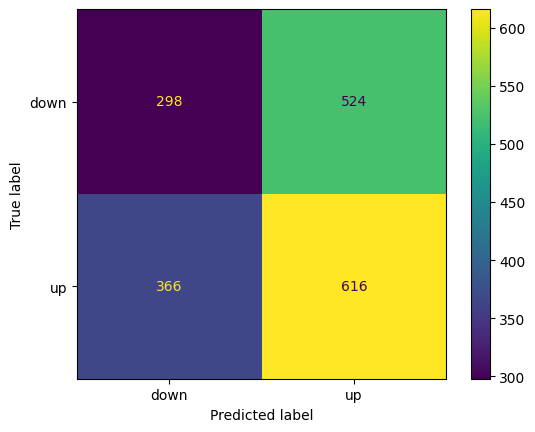

In [44]:
y_pred = model.predict(test_data)
y_test = test_data['DP']

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot();
#* y_test 是測試集的實際標籤，用來和模型的預測結果進行比較

In [46]:
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

              precision    recall  f1-score   support

        down      0.449     0.363     0.401       822
          up      0.540     0.627     0.581       982

    accuracy                          0.507      1804
   macro avg      0.495     0.495     0.491      1804
weighted avg      0.499     0.507     0.499      1804



In [48]:
from sklearn.metrics import recall_score

In [49]:
temp = [recall_score(y_test, y_pred, average=None)[0],
        recall_score(y_test, y_pred, average=None)[1],
        recall_score(y_test, y_pred, average=None).sum(),
        accuracy_score(y_test, y_pred)]

Result = pd.DataFrame([temp], columns = ['recall_0', 'recall_1', 'recall_sum', 'acc'], index = ['Result'])
Result

,recall_0,recall_1,recall_sum,acc
Result,0.362530,0.627291,0.989822,0.506652
